# Nestle DCF Case Study

This case study applies the valuation notebooks to a Nestle-like consumer staples company. The inputs are synthetic and rounded for learning, so the notebook is reproducible offline and should not be treated as investment advice.

Abbreviations used in this notebook:

- **DCF**: Discounted Cash Flow, a valuation method based on present values of future cash flows.
- **FCF**: Free Cash Flow, cash generated after capital expenditures.
- **WACC**: Weighted Average Cost of Capital, the discount rate for free cash flows to the firm.
- **TV**: Terminal Value, the estimated value after the explicit forecast period.
- **EV**: Enterprise Value, the value of the operating business.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

Nestle is a useful valuation case because it represents the kind of mature, global, defensive company where a DCF can be meaningful. The investment question is not whether sales can double quickly. It is whether stable revenue, margins, cash conversion, and modest growth justify the current market value.

A DCF case study should connect four layers:

- Company fundamentals: revenue, margin, free cash flow, and balance sheet.
- Forecast assumptions: growth, margin stability, and reinvestment needs.
- Discounting: WACC and terminal growth.
- Market comparison: implied value versus current market price.

## 2. Mathematics

Revenue forecast:

$$
Revenue_t = Revenue_{t-1} \times (1 + g_{revenue})
$$

Free cash flow:

$$
FCF_t = Revenue_t \times FCF\ Margin_t
$$

Present value of explicit cash flows:

$$
PV_{FCF} = \sum_{t=1}^{N} \frac{FCF_t}{(1 + WACC)^t}
$$

Terminal value:

$$
TV = \frac{FCF_N \times (1 + g_{terminal})}{WACC - g_{terminal}}
$$

Enterprise value:

$$
EV = PV_{FCF} + \frac{TV}{(1 + WACC)^N}
$$

Equity value per share:

$$
\text{Value per Share} = \frac{EV - \text{Net Debt}}{\text{Shares Outstanding}}
$$

## 3. Implementation

We will build a full DCF from simplified operating assumptions. The model separates assumptions, forecast, valuation output, and sensitivity analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

assumptions = {
    "current_revenue": 102_000,
    "starting_fcf_margin": 0.132,
    "target_fcf_margin": 0.140,
    "revenue_growth": 0.035,
    "wacc": 0.060,
    "terminal_growth": 0.020,
    "years": 5,
    "net_debt": 35_000,
    "shares_outstanding": 2_650,
    "current_share_price": 96.00,
}


def build_forecast(current_revenue, starting_fcf_margin, target_fcf_margin, revenue_growth, years):
    forecast_years = np.arange(1, years + 1)
    revenue = np.array([current_revenue * (1 + revenue_growth) ** year for year in forecast_years])
    fcf_margin = np.linspace(starting_fcf_margin, target_fcf_margin, years)
    fcf = revenue * fcf_margin

    return pd.DataFrame({
        "year": forecast_years,
        "revenue": revenue,
        "fcf_margin": fcf_margin,
        "free_cash_flow": fcf,
    })


def dcf_from_forecast(forecast, wacc, terminal_growth, net_debt, shares_outstanding):
    if wacc <= terminal_growth:
        raise ValueError("WACC must be greater than terminal growth.")

    discount_factors = (1 + wacc) ** forecast["year"]
    forecast = forecast.copy()
    forecast["pv_fcf"] = forecast["free_cash_flow"] / discount_factors

    final_fcf = forecast["free_cash_flow"].iloc[-1]
    terminal_value = final_fcf * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_terminal_value = terminal_value / ((1 + wacc) ** forecast["year"].iloc[-1])
    enterprise_value = forecast["pv_fcf"].sum() + pv_terminal_value
    equity_value = enterprise_value - net_debt
    value_per_share = equity_value / shares_outstanding

    summary = pd.Series({
        "pv_explicit_fcfs": forecast["pv_fcf"].sum(),
        "terminal_value": terminal_value,
        "pv_terminal_value": pv_terminal_value,
        "enterprise_value": enterprise_value,
        "net_debt": net_debt,
        "equity_value": equity_value,
        "value_per_share": value_per_share,
        "terminal_value_share_of_ev": pv_terminal_value / enterprise_value,
    })

    return forecast, summary

In [2]:
forecast = build_forecast(
    current_revenue=assumptions["current_revenue"],
    starting_fcf_margin=assumptions["starting_fcf_margin"],
    target_fcf_margin=assumptions["target_fcf_margin"],
    revenue_growth=assumptions["revenue_growth"],
    years=assumptions["years"],
)

forecast, valuation_summary = dcf_from_forecast(
    forecast=forecast,
    wacc=assumptions["wacc"],
    terminal_growth=assumptions["terminal_growth"],
    net_debt=assumptions["net_debt"],
    shares_outstanding=assumptions["shares_outstanding"],
)

forecast.round(2)

,year,revenue,fcf_margin,free_cash_flow,pv_fcf
0,1,105570.00,0.13,13935.24,13146.45
1,2,109264.95,0.13,14641.50,13030.89
2,3,113089.22,0.14,15380.13,12913.46
3,4,117047.35,0.14,16152.53,12794.32
4,5,121144.00,0.14,16960.16,12673.62


In [3]:
valuation_summary.to_frame("value").round(2)

,value
pv_explicit_fcfs,64558.73
terminal_value,432484.09
pv_terminal_value,323177.27
enterprise_value,387736.01
net_debt,35000.00
equity_value,352736.01
value_per_share,133.11
terminal_value_share_of_ev,0.83


## 4. Visualization

The forecast should be checked visually. A mature defensive company case should not rely on extreme growth or sudden margin expansion unless there is strong evidence.

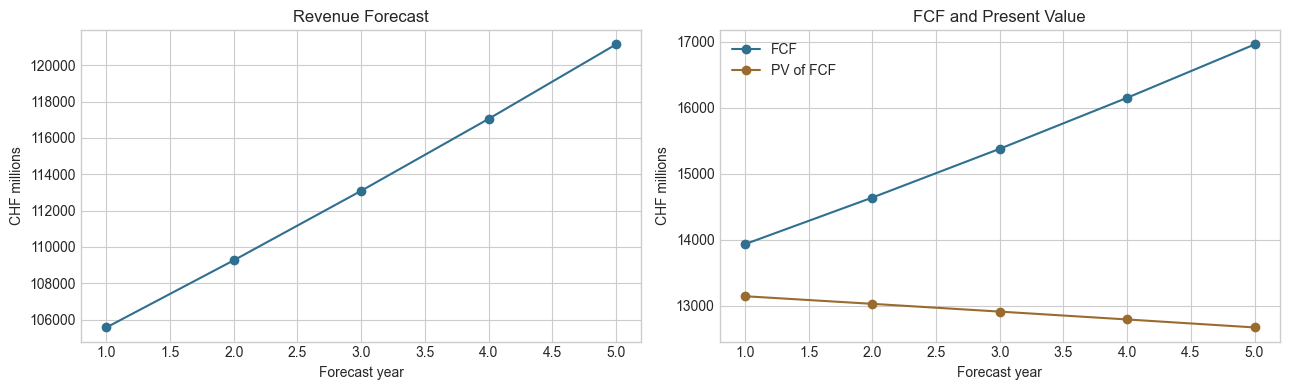

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

forecast.plot(x="year", y="revenue", marker="o", ax=axes[0], color="#2f6f8f", legend=False)
axes[0].set_title("Revenue Forecast")
axes[0].set_xlabel("Forecast year")
axes[0].set_ylabel("CHF millions")

forecast.plot(x="year", y=["free_cash_flow", "pv_fcf"], marker="o", ax=axes[1], color=["#2f6f8f", "#9a6b2f"])
axes[1].set_title("FCF and Present Value")
axes[1].set_xlabel("Forecast year")
axes[1].set_ylabel("CHF millions")
axes[1].legend(["FCF", "PV of FCF"])

plt.tight_layout()
plt.show()

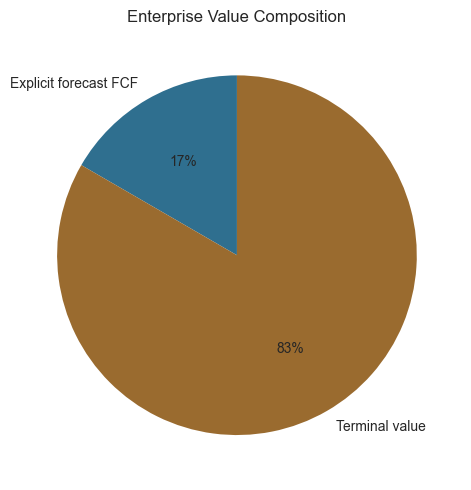

In [5]:
value_split = pd.Series({
    "Explicit forecast FCF": valuation_summary["pv_explicit_fcfs"],
    "Terminal value": valuation_summary["pv_terminal_value"],
})

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(value_split, labels=value_split.index, autopct="%1.0f%%", startangle=90, colors=["#2f6f8f", "#9a6b2f"])
ax.set_title("Enterprise Value Composition")
plt.tight_layout()
plt.show()

In [6]:
wacc_values = np.linspace(0.050, 0.075, 6)
terminal_growth_values = np.linspace(0.010, 0.030, 6)

sensitivity = pd.DataFrame(index=wacc_values, columns=terminal_growth_values, dtype=float)
for wacc in wacc_values:
    for terminal_growth in terminal_growth_values:
        _, case_summary = dcf_from_forecast(
            forecast=forecast.drop(columns=["pv_fcf"]),
            wacc=wacc,
            terminal_growth=terminal_growth,
            net_debt=assumptions["net_debt"],
            shares_outstanding=assumptions["shares_outstanding"],
        )
        sensitivity.loc[wacc, terminal_growth] = case_summary["value_per_share"]

sensitivity.round(2)

,0.010,0.014,0.018,0.022,0.026,0.030
0.050,138.47,153.10,171.38,194.89,226.23,270.11
0.055,121.41,132.61,146.23,163.16,184.75,213.25
0.060,107.76,116.58,127.07,139.78,155.47,175.35
0.065,96.60,103.69,111.99,121.84,133.71,148.28
0.070,87.30,93.11,99.82,107.64,116.89,127.98
0.075,79.43,84.26,89.78,96.12,103.50,112.20


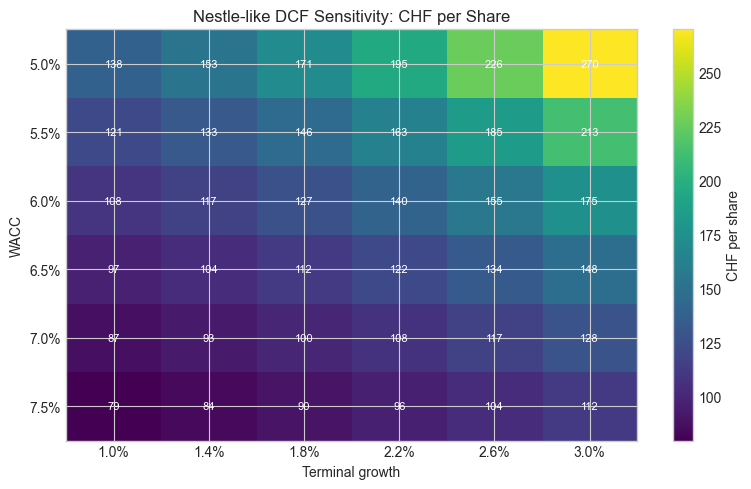

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(sensitivity.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(terminal_growth_values)))
ax.set_xticklabels([f"{g:.1%}" for g in terminal_growth_values])
ax.set_yticks(range(len(wacc_values)))
ax.set_yticklabels([f"{w:.1%}" for w in wacc_values])
ax.set_xlabel("Terminal growth")
ax.set_ylabel("WACC")
ax.set_title("Nestle-like DCF Sensitivity: CHF per Share")

for row in range(sensitivity.shape[0]):
    for col in range(sensitivity.shape[1]):
        ax.text(col, row, f"{sensitivity.values[row, col]:.0f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, label="CHF per share")
plt.tight_layout()
plt.show()

## 5. Application

The base case can be compared with a current market price to frame potential upside or downside. Because the inputs are synthetic, this comparison is only a learning exercise.

In [8]:
value_per_share = valuation_summary["value_per_share"]
current_price = assumptions["current_share_price"]
upside_downside = value_per_share / current_price - 1

print(f"DCF value per share: CHF {value_per_share:,.2f}")
print(f"Illustrative current price: CHF {current_price:,.2f}")
print(f"Implied upside/downside: {upside_downside:.1%}")
print(f"Terminal value share of EV: {valuation_summary['terminal_value_share_of_ev']:.1%}")

DCF value per share: CHF 133.11
Illustrative current price: CHF 96.00
Implied upside/downside: 38.7%
Terminal value share of EV: 83.3%


Interpretation checklist:

- The terminal value share is high, so WACC and terminal growth deserve careful scrutiny.
- The forecast assumes moderate revenue growth and slight FCF margin improvement.
- The model should be compared with relative valuation before forming a conclusion.
- The output is a range of values, not a precise answer.
- A real case would replace the synthetic inputs with sourced financial statements and market data.

## 6. Reflection

- A DCF case study is only as good as its assumptions.
- Mature companies often have high terminal value weight because much of their value is long-term stability.
- Conservative assumptions are especially important when the valuation already depends heavily on terminal value.
- A case study should end with judgment, not just formulas.

Questions to answer after running the notebook:

1. Which assumption would you research first before trusting this valuation?
2. Is the terminal value share reasonable for a mature consumer staples business?
3. What would make the company deserve a higher or lower WACC?
4. How would the conclusion change if relative valuation disagreed with the DCF?